# 03 — Eye Contact Detection

Estimates how long the subject is making eye contact with the camera, using **two complementary signals**:

1. **Iris offset** (from MediaPipe Face Mesh): where the iris sits within the eye socket, normalized by eye width/height. Captures pure eye movement even when the head is still.
2. **Head pose** (from Py-Feat): pitch and yaw in degrees. Captures head orientation — a head turned 45° away is clearly not making eye contact even if the eyes happen to be centered.

A frame is counted as eye contact only when **both** signals agree: iris is near baseline AND head is near-frontal.

**Input:** `data/<video>_merged.parquet` from `00_pipeline.ipynb`.  
**Outputs:** per-frame eye-contact boolean (saved), total seconds, % of video, timeline plot, offset scatter.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

## Config

**Calibration window** — supply a start/end timestamp (seconds) during which the subject is *known* to be looking at the camera. Their mean iris offset during that window becomes the "looking at camera" baseline. Set to `None` to skip calibration (uses 0 as baseline, which assumes a perfectly centered iris means eye contact — only accurate if the camera is directly in front of the subject's face).

**Thresholds** — defaults chosen for a typical laptop-webcam setup. Tune after inspecting the offset scatter plot below.

- `OFFSET_THRESHOLD` = 0.15 (in eye-widths) — how far the iris can drift from baseline and still count.
- `HEAD_PITCH_MAX`, `HEAD_YAW_MAX` = 15° — how far the head can rotate and still count.

In [11]:
VIDEO_STEM = "sample"

# Calibration: a timestamp range (in seconds) when the subject is looking at the camera.
# Set to None to skip calibration and use 0 as baseline.
CALIBRATION_WINDOW = None  # e.g. (0.0, 2.0) to use the first 2 seconds

OFFSET_THRESHOLD = 0.15   # eye-widths (±) around baseline
HEAD_PITCH_MAX = 15.0     # degrees
HEAD_YAW_MAX = 15.0       # degrees

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PARQUET_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.parquet"
META_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.meta.json"
OUT_PATH = DATA_DIR / f"{VIDEO_STEM}_eye_contact.parquet"

print("Input :", PARQUET_PATH)
print("Output:", OUT_PATH)

Input : /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_merged.parquet
Output: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_eye_contact.parquet


In [12]:
df = pd.read_parquet(PARQUET_PATH)
meta = pd.read_json(META_PATH, typ="series")
FPS = float(meta["effective_fps"])
frame_duration_s = 1.0 / FPS
print(f"{len(df)} sampled frames, effective fps = {FPS:.2f}")
df[["frame", "timestamp", "pf_Pitch", "pf_Yaw", "mp_face_l_iris_x", "mp_face_r_iris_x"]].head(3)

165 sampled frames, effective fps = 6.00


,frame,timestamp,pf_Pitch,pf_Yaw,mp_face_l_iris_x,mp_face_r_iris_x
0,0,0.000000,1.107137,4.032975,0.456598,0.538816
1,5,0.166667,-0.308955,0.677106,0.459855,0.542481
2,10,0.333333,-1.049357,0.496601,0.461720,0.544931


## 1. Compute iris offsets

**What this section does:** converts raw MediaPipe landmark coordinates into a single pair of numbers per frame — `offset_x` and `offset_y` — that describe where the iris sits within the eye socket, normalized by eye dimensions.

**Why normalize by eye dimensions:** raw landmark coordinates depend on how big the face appears in frame and where it sits. Normalizing by eye width/height makes the offset scale-invariant — 0.2 means "20% of an eye-width off center" regardless of how close the subject is to the camera.

**Formulas (per eye):**
- `offset_x = (iris_x − eye_mid_x) / eye_width` where `eye_mid_x = (outer_x + inner_x) / 2` and `eye_width = |outer_x − inner_x|`.
- `offset_y = (iris_y − eye_mid_y) / eye_height` where `eye_mid_y = (top_y + bot_y) / 2` and `eye_height = |top_y − bot_y|`.

**Why average the two eyes:** both eyes move together (conjugate gaze), so averaging reduces per-eye landmark noise roughly by √2. We only fall back to single-eye data if one eye isn't detected.

**Sign convention:** `offset_x > 0` means iris shifted toward the outer corner (subject looking sideways). `offset_y > 0` means iris shifted down.

In [13]:
def eye_offset(df, side: str):
    """Return (offset_x, offset_y) Series for one eye, normalized by eye width/height."""
    iris_x = df[f"mp_face_{side}_iris_x"]
    iris_y = df[f"mp_face_{side}_iris_y"]
    outer_x = df[f"mp_face_{side}_eye_outer_x"]
    inner_x = df[f"mp_face_{side}_eye_inner_x"]
    top_y = df[f"mp_face_{side}_eye_top_y"]
    bot_y = df[f"mp_face_{side}_eye_bot_y"]

    mid_x = (outer_x + inner_x) / 2
    mid_y = (top_y + bot_y) / 2
    eye_w = (outer_x - inner_x).abs()
    eye_h = (top_y - bot_y).abs()

    off_x = (iris_x - mid_x) / eye_w
    off_y = (iris_y - mid_y) / eye_h
    # Flip sign of left-eye offset_x so both eyes share the same convention
    # (positive = toward subject's right = screen left).
    if side == "l":
        off_x = -off_x
    return off_x, off_y

lx, ly = eye_offset(df, "l")
rx, ry = eye_offset(df, "r")
df["offset_x"] = pd.concat([lx, rx], axis=1).mean(axis=1)
df["offset_y"] = pd.concat([ly, ry], axis=1).mean(axis=1)

print(df[["offset_x", "offset_y"]].describe().round(3))

       offset_x  offset_y
count   165.000   165.000
mean      0.040    -0.090
std       0.007     0.044
min       0.004    -0.341
25%       0.037    -0.107
50%       0.041    -0.085
75%       0.045    -0.058
max       0.060    -0.005


## 3. Classify each frame

**What this section does:** applies the combined rule — iris near baseline AND head near-frontal — to produce a per-frame boolean `eye_contact` column.

### A note on head pose — pitch, yaw, roll

Py-Feat reports head orientation as three rotation angles in **degrees**, borrowed from aviation. 0° on all three means the head is pointing straight at the camera.

| Axis | Motion | In plain English | Why we gate on it |
|---|---|---|---|
| **Pitch** | nodding up/down | "yes" gesture — chin up (positive) or chin down (negative) | Catches "looking down at notes" or "looking up at the ceiling." |
| **Yaw** | turning left/right | "no" gesture — face turning toward your own shoulder | Catches "turning head to look at someone beside me." |
| **Roll** | tilting sideways | "what?" gesture — ear tipping toward shoulder | **Not gated** — a tilted head (leaning, casual posture) doesn't break eye contact. |

```
     PITCH (nodding)
        ↑  chin up
     ───┼───  → YAW (turning left/right)
        ↓  chin down

   ROLL (tilting): ear to shoulder ↺↻
```

### The rule, spelled out
```
eye_contact = (|offset_x − baseline_x| < OFFSET_THRESHOLD)
           AND (|offset_y − baseline_y| < OFFSET_THRESHOLD)
           AND (|pf_Pitch| < HEAD_PITCH_MAX)
           AND (|pf_Yaw|   < HEAD_YAW_MAX)
```

**Why all four conditions:** the two offset checks catch eye-only glances; the two head-pose checks catch times when the head has turned away and the iris happens to land back at center. Without the pose guard you'd get false positives when someone turns their head to the side while their eyes track back toward the camera for a split second.


In [14]:
if CALIBRATION_WINDOW is None:
    baseline_x = 0.0
    baseline_y = 0.0
    print("No calibration window set — using baseline (0, 0).")
else:
    t0, t1 = CALIBRATION_WINDOW
    cal = df[(df["timestamp"] >= t0) & (df["timestamp"] <= t1)]
    if len(cal) < 3:
        raise ValueError(f"Calibration window {CALIBRATION_WINDOW} contains only {len(cal)} frames; need more")
    baseline_x = float(cal["offset_x"].mean())
    baseline_y = float(cal["offset_y"].mean())
    print(f"Calibrated on {len(cal)} frames in window {CALIBRATION_WINDOW}:")
    print(f"  baseline_x = {baseline_x:+.3f}")
    print(f"  baseline_y = {baseline_y:+.3f}")

No calibration window set — using baseline (0, 0).


## 3. Classify each frame

**What this section does:** applies the combined rule — iris near baseline AND head near-frontal — to produce a per-frame boolean `eye_contact` column.

**The rule, spelled out:**
```
eye_contact = (|offset_x − baseline_x| < OFFSET_THRESHOLD)
           AND (|offset_y − baseline_y| < OFFSET_THRESHOLD)
           AND (|pf_Pitch| < HEAD_PITCH_MAX)
           AND (|pf_Yaw|   < HEAD_YAW_MAX)
```

**Why all four conditions:** the two offset checks catch eye-only glances; the two head-pose checks catch times when the head has turned away and the iris happens to land back at center. Without the pose guard you'd get false positives when someone turns their head to the side while their eyes track back toward the camera for a split second.

**Roll is intentionally not gated** — a tilted head (subject leaning) doesn't break eye contact.

In [15]:
ok_x = (df["offset_x"] - baseline_x).abs() < OFFSET_THRESHOLD
ok_y = (df["offset_y"] - baseline_y).abs() < OFFSET_THRESHOLD
ok_pitch = df["pf_Pitch"].abs() < HEAD_PITCH_MAX
ok_yaw = df["pf_Yaw"].abs() < HEAD_YAW_MAX

df["eye_contact"] = (ok_x & ok_y & ok_pitch & ok_yaw).fillna(False)

# Diagnostic: what fraction of frames each sub-condition passed
diag = pd.Series({
    "iris_x_ok_%": round(100 * ok_x.mean(), 1),
    "iris_y_ok_%": round(100 * ok_y.mean(), 1),
    "pitch_ok_%": round(100 * ok_pitch.mean(), 1),
    "yaw_ok_%": round(100 * ok_yaw.mean(), 1),
    "all_ok_%": round(100 * df["eye_contact"].mean(), 1),
})
diag

iris_x_ok_%    100.0
iris_y_ok_%     93.9
pitch_ok_%      93.9
yaw_ok_%       100.0
all_ok_%        87.9
dtype: float64

## 4. Summary numbers

**What this section does:** rolls the per-frame boolean up into the headline numbers: total eye-contact time in seconds and percentage of the video.

**What to report in a study:** the percentage is usually more comparable across videos of different lengths. Report raw seconds alongside so short clips don't look artificially high from a tiny sample.

In [16]:
eye_frames = int(df["eye_contact"].sum())
total_frames = int(df["eye_contact"].notna().sum())
seconds_eye = eye_frames * frame_duration_s
seconds_total = total_frames * frame_duration_s
pct = 100 * eye_frames / total_frames if total_frames else float("nan")

summary = pd.Series({
    "eye_contact_seconds": round(seconds_eye, 2),
    "total_seconds": round(seconds_total, 2),
    "pct_of_video": round(pct, 1),
    "baseline_x": round(baseline_x, 3),
    "baseline_y": round(baseline_y, 3),
    "offset_threshold": OFFSET_THRESHOLD,
    "pitch_max_deg": HEAD_PITCH_MAX,
    "yaw_max_deg": HEAD_YAW_MAX,
})
summary

eye_contact_seconds    24.17
total_seconds          27.50
pct_of_video           87.90
baseline_x              0.00
baseline_y              0.00
offset_threshold        0.15
pitch_max_deg          15.00
yaw_max_deg            15.00
dtype: float64

## 5. Timeline plot

**What this chart shows:** four stacked panels over the same x-axis (time):
1. Iris offset_x and offset_y over time, with ± threshold band around baseline shaded.
2. Head pitch and yaw over time, with ±15° band shaded.
3. Per-frame eye_contact boolean as a bar strip.

**What to look for:** offsets outside the band or pose outside the band should correspond to non-contact stretches. If a stretch is marked "contact" but a signal is clearly out of band, you've got a bug (or a detection failure) to investigate.

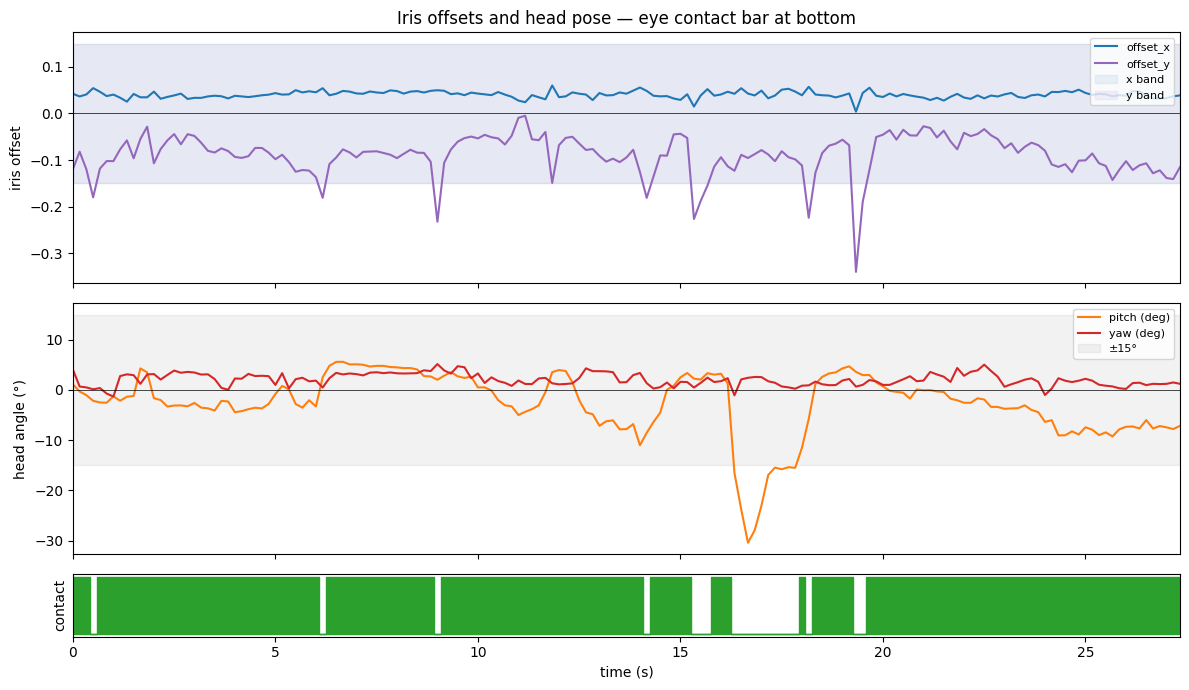

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 2, 0.5]})
t = df["timestamp"].to_numpy()

ax0 = axes[0]
ax0.plot(t, df["offset_x"], color="tab:blue", label="offset_x")
ax0.plot(t, df["offset_y"], color="tab:purple", label="offset_y")
ax0.axhspan(baseline_x - OFFSET_THRESHOLD, baseline_x + OFFSET_THRESHOLD, color="tab:blue", alpha=0.08, label="x band")
ax0.axhspan(baseline_y - OFFSET_THRESHOLD, baseline_y + OFFSET_THRESHOLD, color="tab:purple", alpha=0.08, label="y band")
ax0.axhline(0, color="k", lw=0.5)
ax0.set_ylabel("iris offset")
ax0.legend(loc="upper right", fontsize=8)
ax0.set_title("Iris offsets and head pose — eye contact bar at bottom")

ax1 = axes[1]
ax1.plot(t, df["pf_Pitch"], color="tab:orange", label="pitch (deg)")
ax1.plot(t, df["pf_Yaw"], color="tab:red", label="yaw (deg)")
ax1.axhspan(-HEAD_PITCH_MAX, HEAD_PITCH_MAX, color="k", alpha=0.05, label=f"±{HEAD_PITCH_MAX:.0f}°")
ax1.axhline(0, color="k", lw=0.5)
ax1.set_ylabel("head angle (°)")
ax1.legend(loc="upper right", fontsize=8)

ax2 = axes[2]
ax2.fill_between(t, 0, df["eye_contact"].astype(int), color="tab:green", step="mid")
ax2.set_yticks([])
ax2.set_xlabel("time (s)")
ax2.set_ylabel("contact")
ax2.set_xlim(t.min(), t.max())

plt.tight_layout()
plt.show()

## 6. Offset scatter (for threshold tuning)

**What this chart shows:** every frame plotted by its (offset_x, offset_y), colored by whether the frame was counted as eye contact.

**How to use it:** if the green cluster is well-separated from the red points, your threshold is reasonable. If there's no clear cluster (green points smeared across the plot), either calibration failed or the subject moved their gaze a lot — consider a tighter threshold or tighter pose limits.

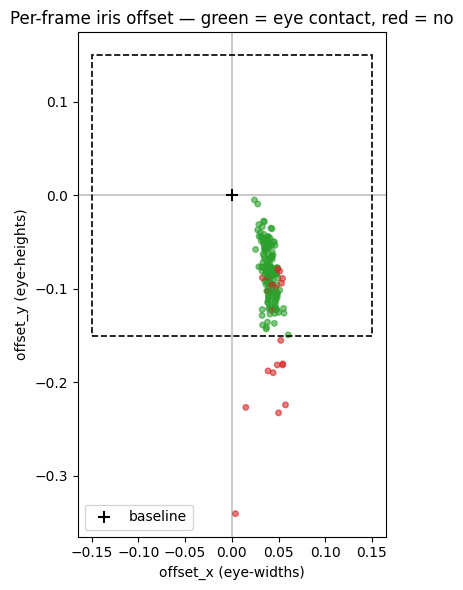

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = df["eye_contact"].map({True: "tab:green", False: "tab:red"})
ax.scatter(df["offset_x"], df["offset_y"], c=colors, s=16, alpha=0.6)
ax.scatter([baseline_x], [baseline_y], c="k", s=80, marker="+", label="baseline")
from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((baseline_x - OFFSET_THRESHOLD, baseline_y - OFFSET_THRESHOLD),
                       2*OFFSET_THRESHOLD, 2*OFFSET_THRESHOLD,
                       fill=False, lw=1.2, ls="--", edgecolor="k"))
ax.axhline(0, color="k", lw=0.3); ax.axvline(0, color="k", lw=0.3)
ax.set_xlabel("offset_x (eye-widths)"); ax.set_ylabel("offset_y (eye-heights)")
ax.set_title("Per-frame iris offset — green = eye contact, red = no")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Save per-frame eye-contact column

In [19]:
out = df[["frame", "timestamp", "offset_x", "offset_y", "pf_Pitch", "pf_Yaw", "eye_contact"]].copy()
out.to_parquet(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}  ({len(out)} rows, {int(out['eye_contact'].sum())} eye-contact frames)")

Saved: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_eye_contact.parquet  (165 rows, 145 eye-contact frames)
